# Project 1 Pipeline: Movie Recommendation Dataset and Analysis

This notebook creates a secondary relational dataset from the MovieLens “latest small” dataset and uses it to build a movie recommendation pipeline. The notebook first cleans and normalizes the raw data into multiple related tables. Then it loads the processed data into DuckDB, runs SQL queries for exploration, and implements both a baseline recommendation model and a collaborative filtering model. The goal is to generate movie recommendations in a way that is structured, explainable, and aligned with the relational model.

#### Imports and Set up

In [2]:
import os
import logging
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Create folders in the project root, not inside pipeline/
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
os.makedirs("../logs", exist_ok=True)

# Write logs to the top-level logs folder
logging.basicConfig(
    filename="../logs/pipeline.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Pipeline started")

#### Raw Data Loading

In this section, the raw MovieLens files are loaded from the `data/raw` folder. Error handling is included so that the notebook clearly reports if any file is missing or cannot be read.

In [3]:
# Load raw MovieLens data from the top-level data/raw folder
try:
    movies = pd.read_csv("../data/raw/movies.csv")
    ratings = pd.read_csv("../data/raw/ratings.csv")
    tags = pd.read_csv("../data/raw/tags.csv")
    links = pd.read_csv("../data/raw/links.csv")
    logging.info("Raw data loaded successfully")
except FileNotFoundError as e:
    logging.error(f"Missing file: {e}")
    raise
except Exception as e:
    logging.error(f"Unexpected error while loading raw data: {e}")
    raise

In [4]:
print("movies:", movies.shape)
print("ratings:", ratings.shape)
print("tags:", tags.shape)
print("links:", links.shape)

display(movies.head())
display(ratings.head())
display(tags.head())
display(links.head())

movies: (9742, 3)
ratings: (100836, 4)
tags: (3683, 4)
links: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


#### Processed Dataset Creation

In this section, the raw MovieLens files are transformed into a more normalized relational dataset. A users table is created from unique user IDs, release year is extracted from movie titles, and the multi-valued genres field is normalized into separate `genres` and `movie_genres` tables. This produces a secondary dataset with seven related tables that can support recommendation analysis.

In [5]:
# Create a users table from all unique user IDs that appear in ratings and tags
users = pd.DataFrame({
    "userId": sorted(pd.concat([ratings["userId"], tags["userId"]]).unique())
})

print("users:", users.shape)
display(users.head())

users: (610, 1)


,userId
0,1
1,2
2,3
3,4
4,5


In [6]:
# Copy the movies table and extract the release year from the title
movies_clean = movies.copy()
movies_clean["releaseYear"] = movies_clean["title"].str.extract(r"\((\d{4})\)")
movies_clean["releaseYear"] = pd.to_numeric(movies_clean["releaseYear"], errors="coerce")

print("movies_clean:", movies_clean.shape)
display(movies_clean.head())

movies_clean: (9742, 4)


,movieId,title,genres,releaseYear
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0
4,5,Father of the Bride Part II (1995),Comedy,1995.0


In [7]:
# Split the multi-valued genres field into one genre per row
movie_genres = movies_clean[["movieId", "genres"]].copy()
movie_genres["genreName"] = movie_genres["genres"].str.split("|")
movie_genres = movie_genres.explode("genreName")
movie_genres = movie_genres[["movieId", "genreName"]].drop_duplicates()

print("movie_genres step 1:", movie_genres.shape)
display(movie_genres.head())

movie_genres step 1: (22084, 2)


,movieId,genreName
0,1,Adventure
0,1,Animation
0,1,Children
0,1,Comedy
0,1,Fantasy


In [8]:
# Create a separate genres table with one unique row per genre
genres = pd.DataFrame({
    "genreName": sorted(movie_genres["genreName"].dropna().unique())
})

genres["genreId"] = range(1, len(genres) + 1)
genres = genres[["genreId", "genreName"]]

print("genres:", genres.shape)
display(genres.head())

genres: (20, 2)


,genreId,genreName
0,1,(no genres listed)
1,2,Action
2,3,Adventure
3,4,Animation
4,5,Children


In [9]:
# Replace genre names with genre IDs in the bridge table
movie_genres = movie_genres.merge(genres, on="genreName", how="left")
movie_genres = movie_genres[["movieId", "genreId"]].drop_duplicates()

print("movie_genres final:", movie_genres.shape)
display(movie_genres.head())

movie_genres final: (22084, 2)


,movieId,genreId
0,1,3
1,1,4
2,1,5
3,1,6
4,1,10


In [10]:
# Keep the final versions of the processed tables
movies_final = movies_clean[["movieId", "title", "releaseYear"]].copy()
ratings_final = ratings.copy()
tags_final = tags.copy()
links_final = links.copy()

print("users:", users.shape)
print("movies_final:", movies_final.shape)
print("ratings_final:", ratings_final.shape)
print("tags_final:", tags_final.shape)
print("links_final:", links_final.shape)
print("genres:", genres.shape)
print("movie_genres:", movie_genres.shape)

users: (610, 1)
movies_final: (9742, 3)
ratings_final: (100836, 4)
tags_final: (3683, 4)
links_final: (9742, 3)
genres: (20, 2)
movie_genres: (22084, 2)


#### Save Processed Data

The processed relational tables are saved as CSV files in the `data/processed` folder. These files form the secondary dataset used in the rest of the project.

In [11]:
# Save processed tables to the top-level data/processed folder
try:
    users.to_csv("../data/processed/users.csv", index=False)
    movies_final.to_csv("../data/processed/movies.csv", index=False)
    ratings_final.to_csv("../data/processed/ratings.csv", index=False)
    tags_final.to_csv("../data/processed/tags.csv", index=False)
    links_final.to_csv("../data/processed/links.csv", index=False)
    genres.to_csv("../data/processed/genres.csv", index=False)
    movie_genres.to_csv("../data/processed/movie_genres.csv", index=False)
    logging.info("Processed data saved successfully")
except Exception as e:
    logging.error(f"Error saving processed data: {e}")
    raise

#### Load Processed Data into DuckDB

This section loads the processed CSV files into DuckDB using Python. DuckDB makes it easy to run SQL queries directly on the relational dataset without needing a separate database server.

In [12]:
# Connect to DuckDB and load the processed CSV files as tables
con = duckdb.connect()

con.execute("CREATE OR REPLACE TABLE users AS SELECT * FROM '../data/processed/users.csv'")
con.execute("CREATE OR REPLACE TABLE movies AS SELECT * FROM '../data/processed/movies.csv'")
con.execute("CREATE OR REPLACE TABLE ratings AS SELECT * FROM '../data/processed/ratings.csv'")
con.execute("CREATE OR REPLACE TABLE tags AS SELECT * FROM '../data/processed/tags.csv'")
con.execute("CREATE OR REPLACE TABLE links AS SELECT * FROM '../data/processed/links.csv'")
con.execute("CREATE OR REPLACE TABLE genres AS SELECT * FROM '../data/processed/genres.csv'")
con.execute("CREATE OR REPLACE TABLE movie_genres AS SELECT * FROM '../data/processed/movie_genres.csv'")

logging.info("Processed CSV files loaded into DuckDB")
print(con.execute("SHOW TABLES").fetchall())

[('genres',), ('links',), ('movie_genres',), ('movies',), ('ratings',), ('tags',), ('users',)]


#### Exploratory SQL Queries

Before building recommendation models, SQL queries are used to explore the dataset. These queries help show patterns in the data and prepare for the recommendation analysis.

In [13]:
# Count how many ratings are associated with each genre
query1 = con.execute("""
SELECT g.genreName, COUNT(*) AS rating_count
FROM ratings r
JOIN movie_genres mg ON r.movieId = mg.movieId
JOIN genres g ON mg.genreId = g.genreId
GROUP BY g.genreName
ORDER BY rating_count DESC
LIMIT 10
""").fetchdf()

query1

,genreName,rating_count
0,Drama,41928
1,Comedy,39053
2,Action,30635
3,Thriller,26452
4,Adventure,24161
5,Romance,18124
6,Sci-Fi,17243
7,Crime,16681
8,Fantasy,11834
9,Children,9208


In [14]:
# Find the highest rated movies with at least 50 ratings
query2 = con.execute("""
SELECT m.title, AVG(r.rating) AS avg_rating, COUNT(*) AS num_ratings
FROM ratings r
JOIN movies m ON r.movieId = m.movieId
GROUP BY m.title
HAVING COUNT(*) > 50
ORDER BY avg_rating DESC
LIMIT 10
""").fetchdf()

query2

,title,avg_rating,num_ratings
0,"Shawshank Redemption, The (1994)",4.429022,317
1,"Godfather, The (1972)",4.289062,192
2,Fight Club (1999),4.272936,218
3,Cool Hand Luke (1967),4.271930,57
4,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
5,Rear Window (1954),4.261905,84
6,"Godfather: Part II, The (1974)",4.259690,129
7,"Departed, The (2006)",4.252336,107
8,Goodfellas (1990),4.250000,126
9,Casablanca (1942),4.240000,100


#### Baseline Recommendation Model
A baseline recommendation model was implemented using average ratings and popularity. Movies are ranked based on their average rating, with a minimum number of ratings required to make the recommendations more reliable.

#### Why This Approach Was Used
This model provides a simple starting point for recommendations and helps identify movies that are widely liked by many users. However, it does not account for individual user preferences, so the same movies are recommended to everyone.

In [15]:
# Recommend movies that are highly rated and have enough ratings to be reliable
recommendations = con.execute("""
SELECT 
    m.movieId,
    m.title,
    AVG(r.rating) AS avg_rating,
    COUNT(r.rating) AS num_ratings
FROM ratings r
JOIN movies m ON r.movieId = m.movieId
GROUP BY m.movieId, m.title
HAVING COUNT(r.rating) > 50
ORDER BY avg_rating DESC
LIMIT 10
""").fetchdf()

recommendations

,movieId,title,avg_rating,num_ratings
0,318,"Shawshank Redemption, The (1994)",4.429022,317
1,858,"Godfather, The (1972)",4.289062,192
2,2959,Fight Club (1999),4.272936,218
3,1276,Cool Hand Luke (1967),4.271930,57
4,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
5,904,Rear Window (1954),4.261905,84
6,1221,"Godfather: Part II, The (1974)",4.259690,129
7,48516,"Departed, The (2006)",4.252336,107
8,1213,Goodfellas (1990),4.250000,126
9,912,Casablanca (1942),4.240000,100


#### Basline Visualization Rationale

A horizontal bar chart is used because movie titles are easier to read on the y-axis. This makes it easier to compare the average ratings of the recommended movies and present the results clearly.

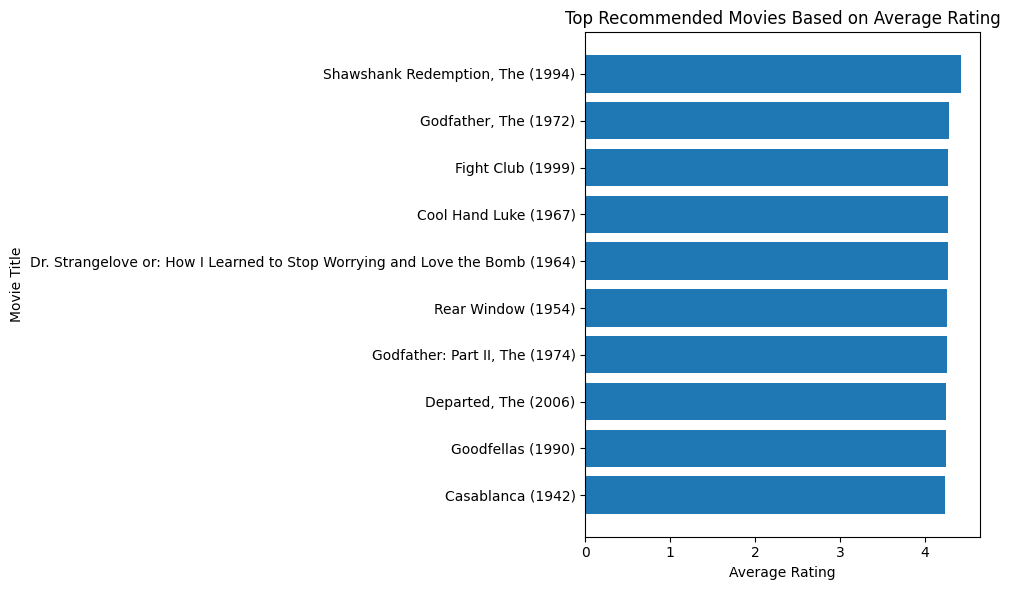

In [16]:
# Visualize the top baseline recommendations
plt.figure(figsize=(10, 6))
plt.barh(recommendations["title"], recommendations["avg_rating"])
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.title("Top Recommended Movies Based on Average Rating")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/top_recommended_movies.png", bbox_inches="tight")
plt.show()

#### Collaborative Filtering Model

A collaborative filtering approach was implemented to generate personalized recommendations. Instead of recommending the same movies to every user, this method identifies users with similar rating patterns and recommends movies those similar users liked.

#### Why This Works

This method captures patterns in user behavior and makes recommendations more personalized than the baseline model. Cosine similarity is used to compare users based on their rating vectors.

In [17]:
# Create a user-movie rating matrix
user_movie = ratings_final.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
).fillna(0)

print(user_movie.shape)
user_movie.head()

(610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# Measure similarity between users based on rating patterns
user_similarity = cosine_similarity(user_movie)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie.index,
    columns=user_movie.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [19]:
# Select a target user and find the most similar users
target_user = 1

similar_users = user_similarity_df[target_user].sort_values(ascending=False)
similar_users = similar_users.drop(target_user)
top_similar_users = similar_users.head(5)

top_similar_users

userId
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
Name: 1, dtype: float64

In [20]:
# Get highly rated movies from similar users
similar_users_ids = top_similar_users.index

similar_users_ratings = ratings_final[
    ratings_final["userId"].isin(similar_users_ids)
]

liked_movies = similar_users_ratings[
    similar_users_ratings["rating"] >= 4
]

In [21]:
# Remove movies the target user has already rated
target_user_movies = ratings_final[
    ratings_final["userId"] == target_user
]["movieId"]

recommendation_candidates = liked_movies[
    ~liked_movies["movieId"].isin(target_user_movies)
]

In [22]:
# Rank candidate movies by how often similar users rated them highly
recommendations_cf = (
    recommendation_candidates
    .groupby("movieId")
    .size()
    .reset_index(name="score")
    .sort_values("score", ascending=False)
    .head(10)
)

recommendations_cf = recommendations_cf.merge(
    movies_final[["movieId", "title"]],
    on="movieId"
)

recommendations_cf

,movieId,score,title
0,1036,5,Die Hard (1988)
1,1200,5,Aliens (1986)
2,1242,4,Glory (1989)
3,1221,4,"Godfather: Part II, The (1974)"
4,858,4,"Godfather, The (1972)"
5,1610,4,"Hunt for Red October, The (1990)"
6,589,4,Terminator 2: Judgment Day (1991)
7,541,4,Blade Runner (1982)
8,2762,4,"Sixth Sense, The (1999)"
9,32,4,Twelve Monkeys (a.k.a. 12 Monkeys) (1995)


#### Visualization Rationale

A horizontal bar chart is again used here because it makes the movie titles readable and allows the recommendation scores to be compared clearly. This chart helps show which movies are the strongest personalized recommendations for the selected user.

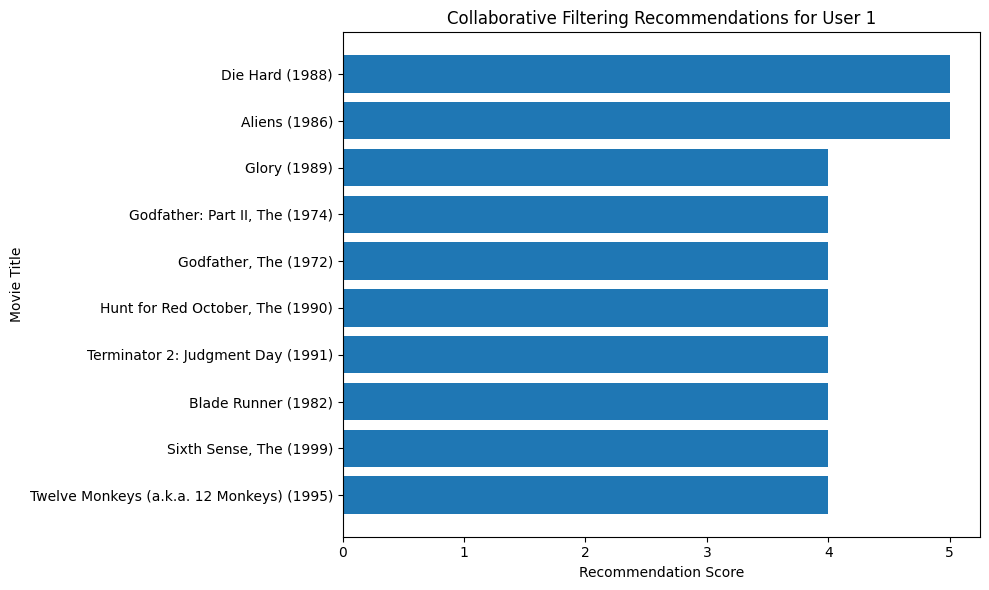

In [23]:
# Visualize the collaborative filtering recommendations
plt.figure(figsize=(10, 6))
plt.barh(recommendations_cf["title"], recommendations_cf["score"])
plt.xlabel("Recommendation Score")
plt.ylabel("Movie Title")
plt.title("Collaborative Filtering Recommendations for User 1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/collaborative_filtering_recommendations.png", bbox_inches="tight")
plt.show()

logging.info("Pipeline completed successfully")